## 特征工程与多项式回归 24-15
 
### 这一节要解决什么问题？

前面我们已经能自己实现多变量线性回归。

但在实际项目中，还会遇到两个问题：

1. 原始特征可能不够好
2. 每次都手写训练代码比较麻烦

所以这一部分要解决的问题是：

> 如何构造更有用的特征，并用工具库快速训练模型？

---

### 核心公式 / 核心概念

特征工程：

> 根据已有数据，构造新的、更有用的特征。

例如：

原始特征：

- 房子长度
- 房子宽度

可以构造新特征：

- 面积 = 长度 × 宽度

多项式特征：

> 当数据不是直线关系时，可以加入 $x^2,x^3$ 等特征，让模型拟合曲线。

scikit-learn：

> Python 中常用的机器学习工具库，可以快速训练线性回归模型。

---

### 这节我需要记住什么？

- 特征工程可以提升模型效果
- 新特征可以由已有特征组合得到
- 多项式回归本质上还是线性回归，只是特征变了
- scikit-learn 可以帮我们快速训练模型
- 手写代码是为了理解原理，sklearn 是为了实际使用方便

最核心：

> 特征工程决定模型能看到什么信息，sklearn 帮我们更方便地训练模型。

---

### 代码如下：



In [6]:
""" 
1,导包
"""
import numpy as np
import matplotlib.pyplot as plt
from lab_utils_multi import zscore_normalize_features, run_gradient_descent_feng
np.set_printoptions(precision=2)


Iteration         0, Cost: 1.65756e+03
Iteration       100, Cost: 6.94549e+02
Iteration       200, Cost: 5.88475e+02
Iteration       300, Cost: 5.26414e+02
Iteration       400, Cost: 4.90103e+02
Iteration       500, Cost: 4.68858e+02
Iteration       600, Cost: 4.56428e+02
Iteration       700, Cost: 4.49155e+02
Iteration       800, Cost: 4.44900e+02
Iteration       900, Cost: 4.42411e+02
w,b found by gradient descent: w: [18.7], b: -52.0834


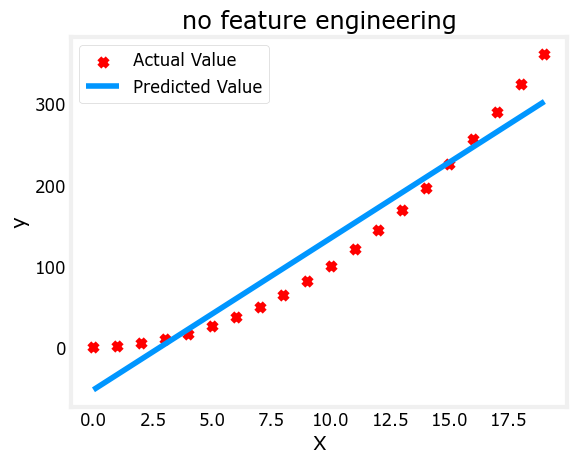

In [ ]:
"""
2,不做特征工程，直接用线性回归拟合二次函数
    作用：
    创建 y = 1 + x^2 的数据，
    但只使用原始特征 x 进行线性回归，
    观察普通直线模型拟合曲线数据的效果。
"""
# 创建输入数据 x
x = np.arange(0, 20, 1) # np.arange(0, 20, 1) 表示生成 0 到 19 的整数
y = 1 + x**2 #真实规律是 y = 1 + x^2，是一条二次曲线

# 把 x 转成二维矩阵
# 原来 x.shape 是 (20,)
# reshape 后 X.shape 是 (20, 1)
X = x.reshape(-1, 1)

# 运行梯度下降，训练线性回归模型
model_w, model_b = run_gradient_descent_feng(
    X, 
    y, 
    iterations=1000, 
    alpha=1e-2
)
plt.scatter(x, y, marker='x', c='r', label="Actual Value") # 画出真实值
plt.title("no feature engineering")                        # 设置标题
plt.plot(x, X @ model_w + model_b, label="Predicted Value") # 画出模型预测值
plt.xlabel("X")
plt.ylabel("y")
plt.legend() # 显示图例
plt.show() # 显示图像

Iteration         0, Cost: 7.32922e+03
Iteration      1000, Cost: 2.24844e-01
Iteration      2000, Cost: 2.22795e-01
Iteration      3000, Cost: 2.20764e-01
Iteration      4000, Cost: 2.18752e-01
Iteration      5000, Cost: 2.16758e-01
Iteration      6000, Cost: 2.14782e-01
Iteration      7000, Cost: 2.12824e-01
Iteration      8000, Cost: 2.10884e-01
Iteration      9000, Cost: 2.08962e-01
w,b found by gradient descent: w: [1.], b: 0.0490


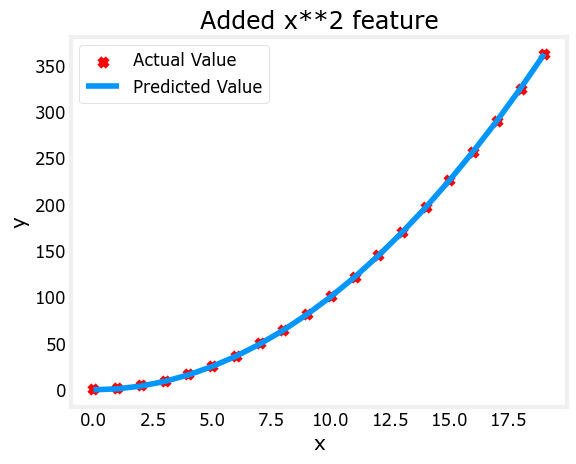

In [ ]:
"""
3,加入二次特征 x**2
    作用：
    原始目标是 y = 1 + x^2。
    如果只用 x，模型只能拟合直线；
    如果把 x^2 作为新特征加入，就可以拟合弯曲曲线。
"""


x = np.arange(0, 20, 1)
y = 1 + x**2

# 特征工程：
# 把原来的 x 换成 x**2
# 也就是让模型使用 x 的平方作为输入特征
X = x**2

# X 必须是二维矩阵
X = X.reshape(-1, 1)

# 运行梯度下降
model_w, model_b = run_gradient_descent_feng(
    X, 
    y, 
    iterations=10000, 
    alpha=1e-5
)
plt.scatter(x, y, marker='x', c='r', label="Actual Value") # 画出真实值
plt.title("Added x**2 feature") # 设置标题
plt.plot(x, np.dot(X, model_w) + model_b, label="Predicted Value") # 画出预测值
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Iteration         0, Cost: 1.14029e+03
Iteration      1000, Cost: 3.28539e+02
Iteration      2000, Cost: 2.80443e+02
Iteration      3000, Cost: 2.39389e+02
Iteration      4000, Cost: 2.04344e+02
Iteration      5000, Cost: 1.74430e+02
Iteration      6000, Cost: 1.48896e+02
Iteration      7000, Cost: 1.27100e+02
Iteration      8000, Cost: 1.08495e+02
Iteration      9000, Cost: 9.26132e+01
w,b found by gradient descent: w: [0.08 0.54 0.03], b: 0.0106


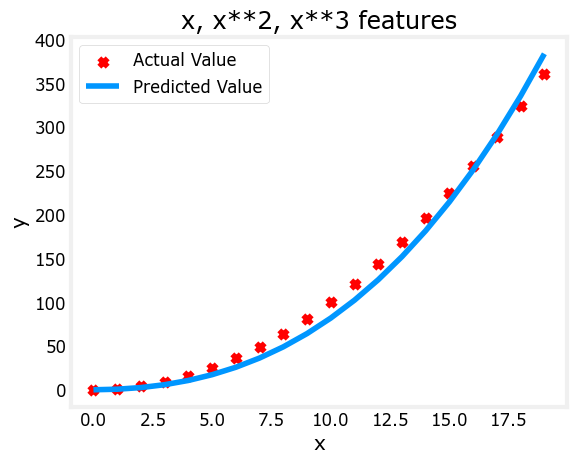

In [10]:
"""
4,同时加入 x、x^2、x^3 三个特征
    作用：
    构造多个候选特征，让模型通过权重大小判断哪个特征更重要。
"""
x = np.arange(0, 20, 1)
y = x**2

# 特征工程：
# 同时加入 x、x^2、x^3 三个特征
# np.c_[] 表示按列拼接多个特征
X = np.c_[x, x**2, x**3]

# 运行梯度下降
model_w, model_b = run_gradient_descent_feng(
    X, 
    y, 
    iterations=10000, 
    alpha=1e-7
)
plt.scatter(x, y, marker='x', c='r', label="Actual Value") # 画出真实值
plt.title("x, x**2, x**3 features") # 设置标题
plt.plot(x, X @ model_w + model_b, label="Predicted Value") # 画出预测值
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

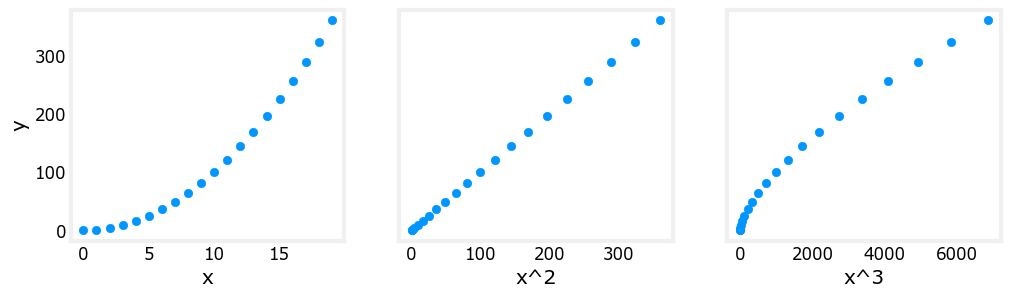

In [ ]:
"""
5,观察不同特征和目标值 y 的关系
    作用：
    分别画出 x、x^2、x^3 与 y 的关系，
    观察哪个特征和 y 更接近线性关系。
"""

# 创建输入数据 x
x = np.arange(0, 20, 1)

# 创建目标数据 y
# 这里真实规律是 y = x^2
y = x**2

# 构造多个特征
# 第一列是 x
# 第二列是 x^2
# 第三列是 x^3
X = np.c_[x, x**2, x**3]

X_features = ['x', 'x^2', 'x^3'] # 给每个特征起名字，方便画图显示

# 创建 1 行 3 列的子图
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# 分别画出每个特征和 y 的关系
for i in range(len(ax)):
    ax[i].scatter(X[:, i], y) # X[:, i] 表示取出第 i 个特征的所有数据
    ax[i].set_xlabel(X_features[i]) # 设置横坐标名称

ax[0].set_ylabel("y") # 设置第一个图的纵坐标名称
plt.show()

In [12]:
"""
6,对多项式特征进行特征缩放
    作用：
    因为 x、x^2、x^3 的数值范围差距很大，
    所以需要使用 Z-score 标准化，让它们的尺度更接近。
"""

x = np.arange(0, 20, 1)

# 构造多项式特征
X = np.c_[x, x**2, x**3]

# 打印原始特征每一列的范围
# np.ptp() = 最大值 - 最小值
# axis=0 表示按列计算
print(np.ptp(X, axis=0))

# 对特征进行 Z-score 标准化
X = zscore_normalize_features(X)

# 打印标准化后每一列的范围
print(np.ptp(X, axis=0))

[  19  361 6859]
[3.3  3.18 3.28]


Iteration         0, Cost: 9.42147e+03
Iteration     10000, Cost: 3.90938e-01
Iteration     20000, Cost: 2.78389e-02
Iteration     30000, Cost: 1.98242e-03
Iteration     40000, Cost: 1.41169e-04
Iteration     50000, Cost: 1.00527e-05
Iteration     60000, Cost: 7.15855e-07
Iteration     70000, Cost: 5.09763e-08
Iteration     80000, Cost: 3.63004e-09
Iteration     90000, Cost: 2.58497e-10
w,b found by gradient descent: w: [5.27e-05 1.13e+02 8.43e-05], b: 123.5000


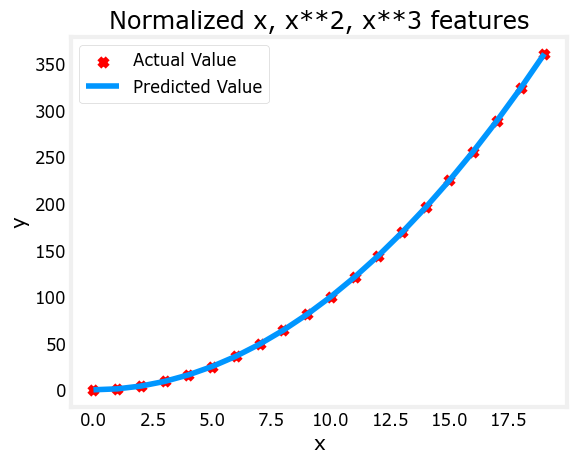

In [13]:
"""
7,使用标准化后的多项式特征训练模型
    作用：
    对 x、x^2、x^3 做标准化后，再运行梯度下降。
    标准化后可以使用更大的学习率 alpha，
    让梯度下降更快收敛。
"""


x = np.arange(0, 20, 1)
y = x**2

# 构造多项式特征
X = np.c_[x, x**2, x**3]

# 对特征进行标准化
X = zscore_normalize_features(X)

# 使用标准化后的 X 运行梯度下降
model_w, model_b = run_gradient_descent_feng(
    X, 
    y, 
    iterations=100000, 
    alpha=1e-1
)


plt.scatter(x, y, marker='x', c='r', label="Actual Value") # 画出真实值
plt.title("Normalized x, x**2, x**3 features")
plt.plot(x, X @ model_w + model_b, label="Predicted Value") # 画出预测值
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Iteration         0, Cost: 2.20188e-01
Iteration    100000, Cost: 1.70074e-02
Iteration    200000, Cost: 1.27603e-02
Iteration    300000, Cost: 9.73032e-03
Iteration    400000, Cost: 7.56440e-03
Iteration    500000, Cost: 6.01412e-03
Iteration    600000, Cost: 4.90251e-03
Iteration    700000, Cost: 4.10351e-03
Iteration    800000, Cost: 3.52730e-03
Iteration    900000, Cost: 3.10989e-03
w,b found by gradient descent: w: [ -1.34 -10.    24.78   5.96 -12.49 -16.26  -9.51   0.59   8.7   11.94
   9.27   0.79 -12.82], b: -0.0073


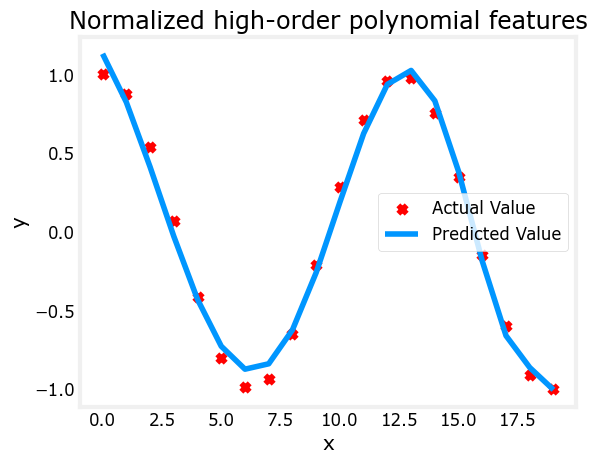

In [14]:
"""
8,使用高阶多项式特征拟合复杂函数
    作用：
    构造 x 到 x^13 的高阶特征，
    尝试用线性回归拟合复杂的非线性函数 cos(x/2)。
"""
x = np.arange(0, 20, 1)

# 创建目标数据 y
# 这里目标函数是 cos(x/2)
y = np.cos(x / 2)

# 构造高阶多项式特征
# 一共构造 x, x^2, x^3, ..., x^13
X = np.c_[
    x,
    x**2,
    x**3,
    x**4,
    x**5,
    x**6,
    x**7,
    x**8,
    x**9,
    x**10,
    x**11,
    x**12,
    x**13
]

# 对高阶特征进行标准化
X = zscore_normalize_features(X)

# 运行梯度下降
model_w, model_b = run_gradient_descent_feng(
    X, 
    y, 
    iterations=1000000, 
    alpha=1e-1
)
plt.scatter(x, y, marker='x', c='r', label="Actual Value") # 画出真实值
plt.title("Normalized high-order polynomial features")
plt.plot(x, X @ model_w + model_b, label="Predicted Value") # 画出预测值
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()